In [1]:
# Env
NUM_AGENTS = 2
HEIGHT = 6
WIDTH = 6
SPAWN_PROB_PER_CELL = 0.05  # 0.05
DESPAWN_PROB_PER_CELL = 0.09

# Training
ENV_ITERATIONS = 1000
DISCOUNT = 0.99
EPSILON = 0.1
LEARNING_RATE = 0.00002
BATCH_SIZE = 32
TARGET_UPDATE_FREQUENCY = 100

# Model
CONV_CHANNELS = [16, 32]
HIDDEN_FEATURES = 128
HIDDEN_LAYERS = 2
KERNEL_SIZE = 3

# Inference
EVAL_STEPS = 1000 # 50000

# Logging
FILENAME = "results_old.csv"
NUM_ENV_CHECKPOINTS = 10


In [2]:
import sys
sys.path.append("../..")
from models.value_cnn import ValueCNNDecentralized
import numpy as np
from orchard.environment import MoveAction, OrchardBasic
from tqdm import tqdm
import torch
from scipy.stats import norm
import copy
import numpy as np
import torch
import matplotlib.pyplot as plt

from models.value_cnn import Transition
from utils import ten_float
from dataclasses import dataclass
from typing import Any
from tadd_helpers.env_functions import *
from tadd_helpers.eval_functions import *
import csv
from pathlib import Path

import ast

if isinstance(CONV_CHANNELS, str):
    CONV_CHANNELS = ast.literal_eval(CONV_CHANNELS)

--- PyTorch is configured to use: cpu ---


In [3]:
history = {
    "loss": [],
    "reward_mean": [],
    "reward_std": [],
    "target_mean": [],
    "target_std": [],
    "pred_mean": [],
    "pred_std": [],
    "corr": [],
}

def log_batch_stats(net: ValueCNNDecentralized, batch_size: int):
    """Compute and store one-line summary statistics based on a sample from the replay buffer."""
    with torch.no_grad():
        if len(net.memory) < batch_size:
            return
            
        device = next(net.parameters()).device

        transitions = net.memory.sample(batch_size)
        batch = Transition(*zip(*transitions))

        states = ten_float(np.stack(batch.state), device=device)
        next_states = ten_float(np.stack(batch.new_state), device=device)
        rewards = ten_float(np.array(batch.reward), device=device)

        preds = net.forward(states).squeeze(1)
        
        # CORRECTED: use net.discount instead of net.trainer.discount
        targets = rewards + net.discount * net.target_net(next_states).squeeze(1)

        preds_np, targets_np, rewards_np = preds.cpu().numpy(), targets.cpu().numpy(), rewards.cpu().numpy()
        corr = np.corrcoef(preds_np, targets_np)[0, 1] if len(preds_np) > 1 else np.nan

    history["reward_mean"].append(np.mean(rewards_np))
    history["reward_std"].append(np.std(rewards_np))
    history["target_mean"].append(np.mean(targets_np))
    history["target_std"].append(np.std(targets_np))
    history["pred_mean"].append(np.mean(preds_np))
    history["pred_std"].append(np.std(preds_np))
    history["corr"].append(corr)
def state_to_raw_dict(s: State) -> dict:
    return {"apples": s.apples, "agents": s.agents}

apples_in_env = []
checkpoint_states = []

In [4]:
def update_move_state(s: State, agent_idx: int, move_vector: np.ndarray):
    """
    Simulates an agent taking an action. Does not modify in place.
    
    Returns:
        tuple: (next_state: State, reward: list[int])
            the reward is a list of length NUM_AGENTS
    """
    old_agent_pos = s.agent_position(agent_idx)
    new_agent_pos = np.clip(old_agent_pos + move_vector, [0, 0], [s.H - 1, s.L - 1]) 
    
    s_new = s.copy()
    s_new.set_agent_position(agent_idx, new_agent_pos)

    rewards_list: list[float] = [0 for _ in range(NUM_AGENTS)]
    return s_new, rewards_list
    

In [5]:
def update_spawn_despawn_and_pick(s: State, agent_idx: int, picked: bool):
    """Simulate the second phase. Agents do not move in this phase but apples may change."""
    rewards: list[float] = [0 for _ in range(NUM_AGENTS)]
    s_new = s.copy()
    if picked:
        picker_pos = s_new.agent_position(agent_idx)
        assert s_new.apples[tuple(picker_pos)] > 0 # must be that an agent picked up apple if picked is True
        s_new.remove_apple_at(picker_pos)
        rewards[agent_idx] = -1 # acting agent gets -1 reward for picking apple
        sum_of_dist_from_agents_to_picker_pos = 0
        for other_agent_idx in range(NUM_AGENTS):
            dist = np.linalg.norm(s_new.agent_position(other_agent_idx) - picker_pos)
            sum_of_dist_from_agents_to_picker_pos += dist
        # assign reward to other agents
        for other_agent_idx in range(NUM_AGENTS):
            if other_agent_idx != agent_idx:
                dist = np.linalg.norm(s_new.agent_position(other_agent_idx) - picker_pos).astype(float)
                if sum_of_dist_from_agents_to_picker_pos > 0:
                    rewards[other_agent_idx] = 2 * (dist / sum_of_dist_from_agents_to_picker_pos)
                else:
                    # this should not happen
                    rewards[other_agent_idx] = 0
    spawn_apples(s_new, SPAWN_PROB_PER_CELL)
    despawn_apples(s_new, DESPAWN_PROB_PER_CELL)
    return s_new, rewards

In [6]:
def update_pick_only_deterministic(s: State, agent_idx: int, picked: bool):
    """
    Deterministic update: Only removes the apple and calculates reward.
    DOES NOT SPAWN/DESPAWN.
    Used for fair Q-value comparison in argmax.
    """
    rewards: list[float] = [0 for _ in range(NUM_AGENTS)]
    s_new = s.copy()
    if picked:
        picker_pos = s_new.agent_position(agent_idx)
        assert s_new.apples[tuple(picker_pos)] > 0 # must be that an agent picked up apple if picked is True
        s_new.remove_apple_at(picker_pos)
        rewards[agent_idx] = -1 # acting agent gets -1 reward for picking apple
        sum_of_dist_from_agents_to_picker_pos = 0
        for other_agent_idx in range(NUM_AGENTS):
            dist = np.linalg.norm(s_new.agent_position(other_agent_idx) - picker_pos)
            sum_of_dist_from_agents_to_picker_pos += dist
        # assign reward to other agents
        for other_agent_idx in range(NUM_AGENTS):
            if other_agent_idx != agent_idx:
                dist = np.linalg.norm(s_new.agent_position(other_agent_idx) - picker_pos).astype(float)
                if sum_of_dist_from_agents_to_picker_pos > 0:
                    rewards[other_agent_idx] = 2 * (dist / sum_of_dist_from_agents_to_picker_pos)
                else:
                    # this should not happen
                    rewards[other_agent_idx] = 0
    return s_new, rewards

### Get CNN Centralized Estimate Value

In [7]:
def Q_team(s_t_plus_1: State, r_team: float, V_team: float):
    return r_team + DISCOUNT * V_team

def r_team_func(r_list: list[float]) -> float:
    return sum(r_list)

def argmax_a_of_Q_team(s_t: State, agent_idx: int, cnns: list[ValueCNNDecentralized]):
    """ This can only be called in phase 1, so we only consider move actions."""
    max_q = -float('inf')
    best_action = MoveAction.STAY
    for action in MoveAction:
        s_t_plus_half, _  = update_move_state(s_t, agent_idx, action.vector)
        if s_t_plus_half.apples[s_t_plus_half.agent_position_tuple(agent_idx)] >= 1:
            pick = True
        else:
            pick = False
        s_t_plus_1, r_t = update_pick_only_deterministic(s_t_plus_half, agent_idx, pick)
        r_team = r_team_func(r_t)
        V_list = []
        for cnn_idx, cnn in enumerate(cnns):
            value = cnn.get_model_reward_prediction_from_raw(state_to_raw_dict(s_t_plus_1), agent_pos=s_t_plus_1.agent_position(cnn_idx)).item()
            V_list.append(value)
        V_team = sum(V_list)
        q_value = Q_team(s_t_plus_1, r_team, V_team)
        if q_value > max_q:
            max_q = q_value
            best_action = action
    return best_action

def train_V(CNNs: list[ValueCNNDecentralized], total_steps: int, s: State, r_team: list[float], s_prime: State):
    """total steps is for target networks

    Args:
        value_CNN_centralized: cnn to train
        total_steps: total steps in training loop
    """
    
    for cnn_idx, cnn in enumerate(CNNs):
        value_CNN_d = cnn
        
        processed_s = value_CNN_d.raw_state_to_nn_input(state_to_raw_dict(s), agent_pos=s.agent_position(cnn_idx))
        processed_s_prime = value_CNN_d.raw_state_to_nn_input(state_to_raw_dict(s_prime), agent_pos=s_prime.agent_position(cnn_idx))
        value_CNN_d.add_experience(processed_s, processed_s_prime, r_team[cnn_idx])
        
        # 3. Train on a batch ONLY if the buffer is large enough
        if len(value_CNN_d.memory) >= BATCH_SIZE:
            log_batch_stats(value_CNN_d, BATCH_SIZE)
            value_CNN_d.train_batch(BATCH_SIZE)
        
        # 4. Periodically update the target network
        if total_steps % TARGET_UPDATE_FREQUENCY == 0:
            value_CNN_d.update_target_net()
        
def log_train_info(s_t, t):
    if t % (ENV_ITERATIONS // NUM_ENV_CHECKPOINTS) == 0 and t > 0:
        apples_in_env.append(np.sum(s_t.apples))
        checkpoint_states.append(s_t.copy())

In [8]:
V_CNNs: list[ValueCNNDecentralized] = []
for _ in range(NUM_AGENTS):
    V_CNNs.append(ValueCNNDecentralized(HEIGHT, WIDTH, LEARNING_RATE,
                                        DISCOUNT, HIDDEN_FEATURES, 
                                        HIDDEN_LAYERS, 
                                        conv_channels=CONV_CHANNELS,
                                        kernel_size=KERNEL_SIZE))

s_0 = init_empty_state(HEIGHT, WIDTH, NUM_AGENTS)

total_steps = 0
s_t = s_0.copy()
for t in tqdm(range(ENV_ITERATIONS), desc="Training"):
    log_train_info(s_t, t)
    c = s_t.get_random_agent_id()
    assert c is not None
    
    # This is first update
    p = np.random.random()
    if p < EPSILON:
        move_action = MoveAction.get_random_action()
    else:
        move_action = argmax_a_of_Q_team(s_t, c, V_CNNs)

    s_t_plus_half, _ = update_move_state(s_t, c, move_action.vector)

    # train_V(V_CNNs, total_steps, s_t, r_t, s_t_plus_half)
    
    # This is second update
    if s_t_plus_half.apples[s_t_plus_half.agent_position_tuple(c)] >= 1:
        pick = True
    else:
        pick = False
    s_t_plus_1, r_t = update_spawn_despawn_and_pick(s_t_plus_half, c, pick)
    train_V(V_CNNs, total_steps, s_t,r_t,s_t_plus_1)
    
    # next iteration prep
    s_t = s_t_plus_1
    total_steps += 1




Training: 100%|██████████| 1000/1000 [00:17<00:00, 58.61it/s]


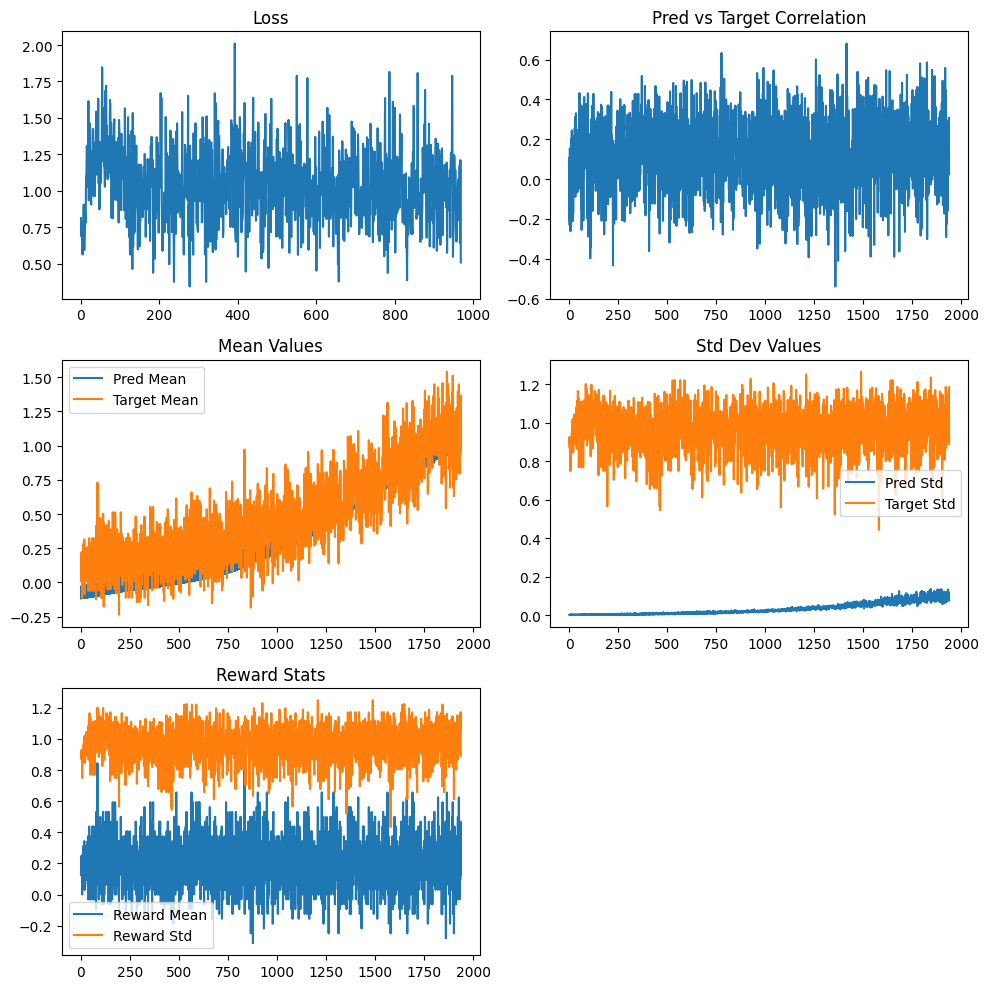

In [9]:
def plot_training_diagnostics(value_CNN_centralized):
    fig, axs = plt.subplots(3, 2, figsize=(10, 10))
    axs = axs.flatten()

    axs[0].plot(value_CNN_centralized.loss_history)
    axs[0].set_title("Loss")

    axs[1].plot(history["corr"])
    axs[1].set_title("Pred vs Target Correlation")

    axs[2].plot(history["pred_mean"], label="Pred Mean")
    axs[2].plot(history["target_mean"], label="Target Mean")
    axs[2].set_title("Mean Values")
    axs[2].legend()

    axs[3].plot(history["pred_std"], label="Pred Std")
    axs[3].plot(history["target_std"], label="Target Std")
    axs[3].set_title("Std Dev Values")
    axs[3].legend()

    axs[4].plot(history["reward_mean"], label="Reward Mean")
    axs[4].plot(history["reward_std"], label="Reward Std")
    axs[4].set_title("Reward Stats")
    axs[4].legend()

    axs[5].axis("off")
    plt.tight_layout()
    plt.show()

plot_training_diagnostics(V_CNNs[0])


In [10]:
def optimal_learned_policy(s: State, agent_idx: int):
    return argmax_a_of_Q_team(s, agent_idx, V_CNNs)

In [11]:
def print_states_func(s_t, t, c, move_action, r_t, s_t_plus_half, picked, r_t_plus_half, s_t_plus_1):
    print(f"State {t}, Acting Agent {c}, Move Action: {move_action}, Reward: {r_t}")
    print(f"\n{str(s_t)}\n")
    print(f"State {t+0.5}, Acting Agent {c}, Picked: {picked}, Reward: {r_t_plus_half}")
    print(f"\n{str(s_t_plus_half)}\n")
    print(f"################################################################")
    
def evaluate_policy(policy_func, num_steps: int = 1000, print_states=False):
    total_rewards = []
    s_0 = init_empty_state(HEIGHT, WIDTH, NUM_AGENTS)
    s_t = s_0.copy()
    for t in tqdm(range(num_steps), desc=f"Evaluating policy"):  # fixed episode length
        c = s_t.get_random_agent_id()
        
        # first update
        move_action = policy_func(s_t, c)
        s_t_plus_half, r_t = update_move_state(s_t, c, move_action.vector)
        # do not track rewards here since it is always 0
        
        # second update
        s_t_plus_1 = s_t_plus_half.copy()
        if s_t_plus_half.apples[s_t_plus_half.agent_position_tuple(c)] >= 1:
            pick = True
        else:
            pick = False
        s_t_plus_1, r_t_plus_half = update_spawn_despawn_and_pick(s_t_plus_half, c, pick)
        team_reward = r_team_func(r_t_plus_half)
        total_rewards.append(team_reward)
        
        if print_states:
            print_states_func(s_t, t, c, move_action, r_t, s_t_plus_half, pick, r_t_plus_half, s_t_plus_1)
            
        # next iteration prep
        s_t = s_t_plus_1


    return total_rewards

In [12]:
random_rewards = evaluate_policy(random_policy, num_steps=EVAL_STEPS)
nearest_rewards = evaluate_policy(nearest_policy, num_steps=EVAL_STEPS)
learned_rewards = evaluate_policy(optimal_learned_policy, num_steps=EVAL_STEPS)


Evaluating policy: 100%|██████████| 1000/1000 [00:04<00:00, 224.33it/s]


In [13]:
print(f"Random Policy: Mean Reward = {np.mean(random_rewards):.4f}, Std Dev = {np.std(random_rewards):.4f}")
print(f"Nearest Policy: Mean Reward = {np.mean(nearest_rewards):.4f}, Std Dev = {np.std(nearest_rewards):.4f}")
print(f"Learned Policy: Mean Reward = {np.mean(learned_rewards):.4f}, Std Dev = {np.std(learned_rewards):.4f}")

Random Policy: Mean Reward = 0.1800, Std Dev = 0.3842
Nearest Policy: Mean Reward = 0.5600, Std Dev = 0.4964
Learned Policy: Mean Reward = 0.4520, Std Dev = 0.4977


In [14]:
# this is debug cell
evaluate_policy(nearest_policy, num_steps=10, print_states=True)

Evaluating policy: 100%|██████████| 10/10 [00:00<00:00, 2772.91it/s]

State 0, Acting Agent 1, Move Action: MoveAction.LEFT, Reward: [0, 0]

--- Empty State (Grid: 6x6) ---

--- Agent Locations ---
  Agent 0: (1, 4)
  Agent 1: (3, 2)

--- Agents (Count) ---
. . . . . .
. . . . 1 .
. . . . . .
. . 1 . . .
. . . . . .
. . . . . .

--- Apples (Count) ---
. . . . . .
. . . . . .
. . . . . .
. . . . . .
. . . . . .
. . . . . .

State 0.5, Acting Agent 1, Picked: False, Reward: [0, 0]

--- Empty State (Grid: 6x6) ---

--- Agent Locations ---
  Agent 0: (1, 4)
  Agent 1: (3, 1)

--- Agents (Count) ---
. . . . . .
. . . . 1 .
. . . . . .
. 1 . . . .
. . . . . .
. . . . . .

--- Apples (Count) ---
. . . . . .
. . . . . .
. . . . . .
. . . . . .
. . . . . .
. . . . . .

################################################################
State 1, Acting Agent 0, Move Action: MoveAction.DOWN, Reward: [0, 0]

--- Empty State (Grid: 6x6) ---

--- Agent Locations ---
  Agent 0: (1, 4)
  Agent 1: (3, 1)

--- Agents (Count) ---
. . . . . .
. . . . 1 .
. . . . . .
. 1 . . . 

[0,
 np.float64(1.0),
 0,
 0,
 0,
 0,
 np.float64(1.0),
 np.float64(1.0),
 0,
 np.float64(1.0)]

In [15]:
print("\n--- Checkpoints ---")
for i in range(NUM_ENV_CHECKPOINTS):
    apples = apples_in_env[i] if i < len(apples_in_env) else 0
    # log apples and states
    print(f"----------Checkpoint {i + 1}--------------")
    print(f"Apples: {apples}")
    print(f"States: {state_to_raw_dict(checkpoint_states[i]) if i < len(checkpoint_states) else {}}")


--- Checkpoints ---
----------Checkpoint 1--------------
Apples: 9
States: {'apples': array([[1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0],
       [0, 1, 1, 0, 0, 0],
       [0, 0, 1, 0, 1, 1],
       [0, 1, 0, 0, 0, 1]]), 'agents': array([[0, 0, 0, 1, 0, 0],
       [0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0]])}
----------Checkpoint 2--------------
Apples: 10
States: {'apples': array([[0, 1, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0],
       [1, 1, 0, 1, 1, 0],
       [1, 0, 0, 1, 1, 0],
       [0, 0, 0, 0, 0, 0]]), 'agents': array([[0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0]])}
----------Checkpoint 3--------------
Apples: 10
States: {'apples': array([[0, 0, 0, 0, 1, 0],
       [1, 0, 0, 0, 0, 0],
       [1, 1, 0, 0, 1, 0],
       [0, 0, 1, 0, 1,

In [16]:
if not Path(FILENAME).exists():
    with open(FILENAME, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["run_name", "iterations" "num_agents", "width", "height", "kernel_size", "conv_channels", "mlp_features", "mlp_layers", "learning_rate", "mean_random_reward", "mean_nearest_reward", "mean_learned_reward"])
        
with open(FILENAME, "a", newline="") as f:
    writer = csv.writer(f)
    # Convert the list of channels to a hyphen-separated string
    conv_channels_str = '-'.join(map(str, CONV_CHANNELS))
    
    # Write the new string to the CSV
    writer.writerow(["Decentralized old no spawnQ", ENV_ITERATIONS, NUM_AGENTS, WIDTH, HEIGHT, KERNEL_SIZE, conv_channels_str, HIDDEN_FEATURES, HIDDEN_LAYERS, LEARNING_RATE, np.mean(random_rewards), np.mean(nearest_rewards), np.mean(learned_rewards)])